<a href="https://colab.research.google.com/github/miguel05mex78-bot/DataScienceMastery/blob/main/Feature%2BSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Environment and libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import chi2, RFE, RFECV, SelectFromModel
from scipy.stats import chi2 as chi2_stats
from sklearn.preprocessing import StandardScaler


#**Data preparation**

In [10]:
# Load the Breast Cancer Wisconsin dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Create a DataFrame for easier manipulation
df = pd.DataFrame(X, columns = feature_names)
df['target'] = y

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(X)
print(y)
df
feature_names



[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

#**DIFFERENT FILTERING METHODS**

##**Pearson Correlation Coefficient**

In [15]:
from scipy.stats import pearsonr

#Calculate Pearson correlation coefficients
correlation_matrix = df.corr()
pearson_values = correlation_matrix.iloc[-1, :-1].abs()

# Rank Features based on Pearson correlation coefficients
feature_ranking = pearson_values.sort_values(ascending=False).index

alpha = 0.05

# Calculate Pearson p-values for all features
pearson_p_values = pd.Series(index=pearson_values.index)
for feature in pearson_values.index:
    pearson_p_values[feature] = pearsonr(df[feature], df['target'])[1]


#  Pearson correlation coefficients, p-values, and Significance
pearson_values_with_significance = pd.DataFrame({
    'Feature': pearson_values.index,
    'Pearson Correlation Coefficient': pearson_values.values,
    'P-Value': pearson_p_values.values,
    'Significance': pearson_p_values < alpha
})

print("\nPearson correlation coefficients, P-Values, and Significance for every feature:")
print(pearson_values_with_significance)


# Select Top Features based on Correlation
# Select the Top k Features
num_features_to_select = 5
selected_features = feature_ranking[:num_features_to_select]

print("\nTop", num_features_to_select, "Features based on Pearson Correlation:")
print(selected_features)

selected_feature_indices = selected_features.to_list()  # Convert Series to list of feature names
selected_feature_indices = [df.columns.get_loc(feature) for feature in selected_feature_indices]

X_train_selected = X_train[:, selected_feature_indices]

# Train the Random Forest Classifier
clf = RandomForestClassifier()
clf.fit(X_train_selected, y_train)

y_pred = clf.predict(X_test[:, selected_feature_indices])

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy with selected features:", accuracy)



Pearson correlation coefficients, P-Values, and Significance for every feature:
                                         Feature  \
mean radius                          mean radius   
mean texture                        mean texture   
mean perimeter                    mean perimeter   
mean area                              mean area   
mean smoothness                  mean smoothness   
mean compactness                mean compactness   
mean concavity                    mean concavity   
mean concave points          mean concave points   
mean symmetry                      mean symmetry   
mean fractal dimension    mean fractal dimension   
radius error                        radius error   
texture error                      texture error   
perimeter error                  perimeter error   
area error                            area error   
smoothness error                smoothness error   
compactness error              compactness error   
concavity error                  co

##**Kendall correlation**

In [ ]:
from scipy.stats import kendalltau

#Calculate kendall correlation coefficients
kendall_values = df.iloc[:, :-1].corrwith(df['target'], method='kendall').abs().sort_values(ascending=False)

# Rank Features based on kendall correlation coefficients
feature_ranking = kendall_values.sort_values(ascending=False).index

alpha = 0.05

# Calculate kendall p-values for all features
kendall_p_values = pd.Series(index=kendall_values.index)
for feature in kendall_values.index:
    kendall_p_values[feature] = kendalltau(df[feature], df['target'])[1]


#  kendall correlation coefficients, p-values, and Significance
kendall_values_with_significance = pd.DataFrame({
    'Feature':kendall_values.index,
    'kendall Correlation Coefficient': kendall_values.values,
    'P-Value': kendall_p_values.values,
    'Significance': kendall_p_values < alpha
})

print("\nkendall correlation coefficients, P-Values, and Significance for every feature:")
print(kendall_values_with_significance)


# Select Top Features based on Correlation
# Select the Top k Features
num_features_to_select = 5
selected_features = feature_ranking[:num_features_to_select]

print("\nTop", num_features_to_select, "Features based on Kendall Correlation:")
print(selected_features)

selected_feature_indices = selected_features.to_list()  # Convert Series to list of feature names
selected_feature_indices = [df.columns.get_loc(feature) for feature in selected_feature_indices]

X_train_selected = X_train[:, selected_feature_indices]

# Train the Random Forest Classifier
clf = RandomForestClassifier()
clf.fit(X_train_selected, y_train)

y_pred = clf.predict(X_test[:, selected_feature_indices])

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy with selected features by Kendall Rank:", accuracy)


<ipython-input-21-ca0a98b85850>:12: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  kendall_p_values = pd.Series(index=kendall_values.index)



kendall correlation coefficients, P-Values, and Significance for every feature:
                                         Feature  \
worst perimeter                  worst perimeter   
worst radius                        worst radius   
worst area                            worst area   
worst concave points        worst concave points   
mean concave points          mean concave points   
mean perimeter                    mean perimeter   
mean area                              mean area   
mean concavity                    mean concavity   
mean radius                          mean radius   
area error                            area error   
worst concavity                  worst concavity   
perimeter error                  perimeter error   
radius error                        radius error   
mean compactness                mean compactness   
worst compactness              worst compactness   
concave points error        concave points error   
worst texture                      

## **Chi-squared**

In [ ]:
# Step 1: Create Contingency Tables and Compute Chi-Squared Values
chi2_values, _ = chi2(X_train, y_train)

# Step 2: Rank Features based on Chi-Squared Values
feature_ranking = np.argsort(chi2_values)[::-1]

# Step 3: Select the Top k Features
num_features_to_select = 5
selected_feature_indices = feature_ranking[:num_features_to_select]

# Step 4: Calculate Critical Chi Value and Determine Significance
alpha = 0.05
df_feature = 1  # Degrees of freedom

# Using scipy.stats to calculate critical chi value
critical_value = chi2_stats.ppf(1 - alpha, df_feature)
is_significant = chi2_values > critical_value

# Display the names, chi-square values, critical chi values, and significance for all features
feature_chi_values = pd.DataFrame({
    'Feature': df.columns[:-1],
    'Chi2 Value': chi2_values,
    'Critical Chi Value': critical_value,
    'Significance': is_significant
})
print("Chi-square values, Critical Chi Values, and Significance for every feature:")
print(feature_chi_values)

# Display the names of the selected features
selected_features = df.columns[selected_feature_indices]
print("\nSelected Features:", selected_features)

# Train a classifier using the selected features
clf = RandomForestClassifier()
clf.fit(X_train[:, selected_feature_indices], y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test[:, selected_feature_indices])

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy with selected features:", accuracy)




Chi-square values, Critical Chi Values, and Significance for every feature:
                    Feature    Chi2 Value  Critical Chi Value  Significance
0               mean radius    210.514840            3.841459          True
1              mean texture     79.494497            3.841459          True
2            mean perimeter   1592.355726            3.841459          True
3                 mean area  42563.130737            3.841459          True
4           mean smoothness      0.120726            3.841459         False
5          mean compactness      4.396908            3.841459          True
6            mean concavity     15.541531            3.841459          True
7       mean concave points      8.552356            3.841459          True
8             mean symmetry      0.234033            3.841459         False
9    mean fractal dimension      0.000025            3.841459         False
10             radius error     25.847577            3.841459          True
11          

## **Principal Components Analysis**

In [ ]:
# 1. Data Preprocessing
# No missing values, and all features are numeric

# 2. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# 3. Compute Covariance Matrix
covariance_matrix = np.cov(X_scaled, rowvar=False)

# 4. Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# 5. Sort Eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# 6. Choose the Number of Components
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Example: Choose the number of components to explain 95% of the variance
num_components = np.argmax(cumulative_explained_variance >= 0.95) + 1

# 8. Feature Ranking
# Order the features based on loadings in descending order
sorted_feature_indices = np.argsort(sorted_eigenvectors[:, 0])[::-1]

# Select the top 5 features
top_5_features = data.feature_names[sorted_feature_indices][:5]

# Print the top 5 features
print("Top 5 Features:")
print(top_5_features)


# Model Training and Evaluation
# Split the data into train and test sets using the top 5 features
selected_indices = np.isin(feature_names, top_5_features)

# Select the corresponding columns in the NumPy array X
X_train_pca_selected_features = X_train[:, selected_indices]
X_test_pca_selected_features = X_test[:, selected_indices]

# Train a model
model = RandomForestClassifier()
model.fit(X_train_pca_selected_features, y_train)

# Make predictions
y_pred = model.predict(X_test_pca_selected_features)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with Top 5 Features: {accuracy * 100:.2f}%")


Top 5 Features:
['smoothness error' 'texture error' 'symmetry error'
 'mean fractal dimension' 'fractal dimension error']
Accuracy with Top 5 Features: 71.05%


### *PCA Plots*

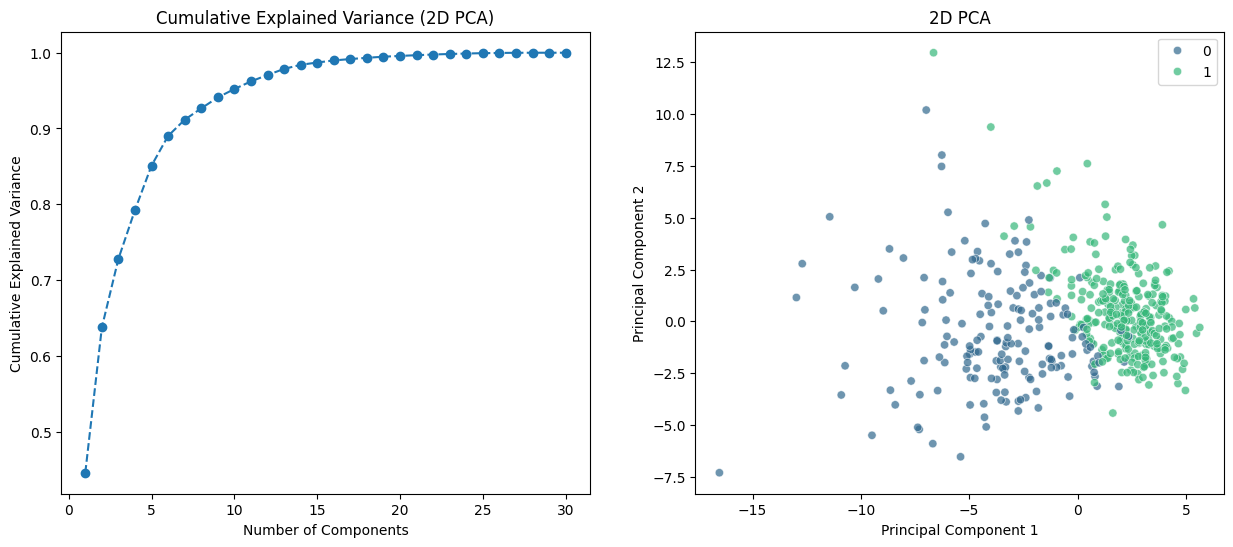

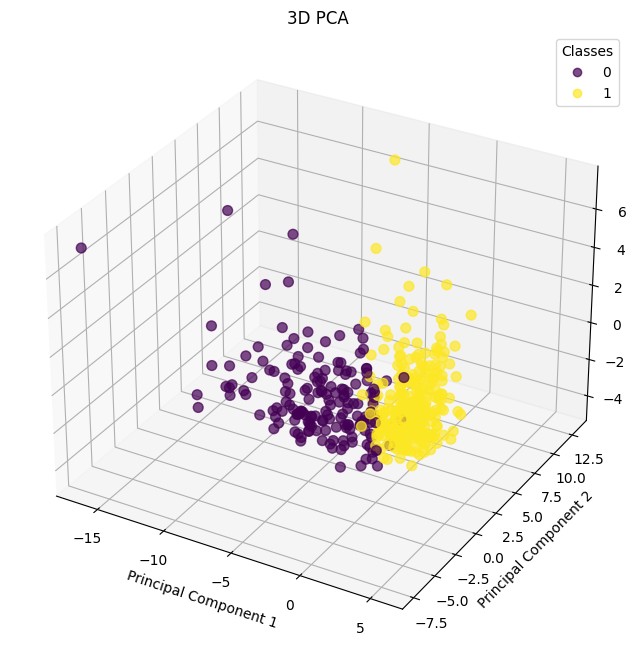

In [ ]:
# 2D and 3D plots
num_components_2d = 2
num_components_3d = 3

# 7. Projection
X_pca_2d = X_scaled.dot(sorted_eigenvectors[:, :num_components_2d])
X_pca_3d = X_scaled.dot(sorted_eigenvectors[:, :num_components_3d])

# Plot explained variance
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance (2D PCA)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

# Plot 2D PCA
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('2D PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Plot 3D PCA
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y_train, cmap='viridis', s=50, alpha=0.7)
ax.set_title('3D PCA')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.legend(*scatter.legend_elements(), title='Classes')
plt.show()



#**WRAPPING**

##**RFE**

In [ ]:
# 2. Feature Ranking with RFE
model = RandomForestClassifier()
num_features_to_select = 5
rfe = RFE(model, n_features_to_select=num_features_to_select)
fit = rfe.fit(X, y)

# Get feature importance scores
feature_importance_scores = fit.estimator_.feature_importances_
features = feature_names[fit.support_]

# Sort features and importance scores in decreasing order
sorted_indices = np.argsort(feature_importance_scores)[::-1]
sorted_features = features[sorted_indices]
sorted_importance_scores = feature_importance_scores[sorted_indices]

# 7. Final Feature Set
final_feature_set = sorted_features

# Display final feature set
print("Final Feature Set:", final_feature_set)

# Split the data into train and test sets using the top 5 features
selected_indices = np.isin(feature_names, final_feature_set)

# Select the corresponding columns in the NumPy array X
X_train_rf_selected_features = X_train[:, selected_indices]
X_test_rf_selected_features = X_test[:, selected_indices]


# Train the final model
final_model = RandomForestClassifier()
final_model.fit(X_train_rf_selected_features, y_train)

# Make predictions
y_pred_rf = final_model.predict(X_test_rf_selected_features)

# Evaluate the final model performance
final_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Final Accuracy with Selected Features: {final_accuracy * 100:.2f}%")

Final Feature Set: ['worst radius' 'worst concave points' 'worst area' 'worst perimeter'
 'mean concave points']
Final Accuracy with Selected Features: 92.11%


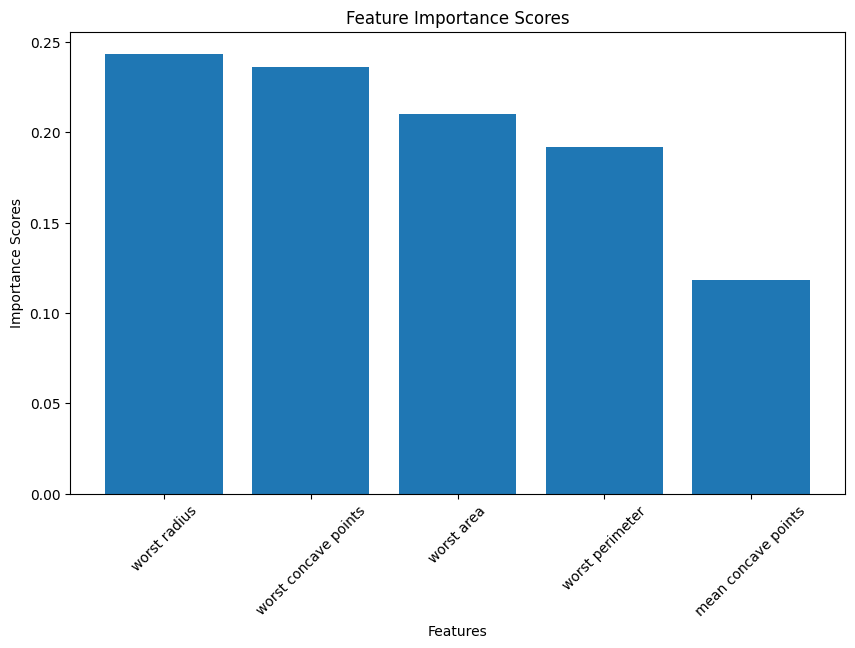

In [ ]:
# Get feature importance scores
feature_importance_scores = fit.estimator_.feature_importances_
features = feature_names[fit.support_]

# Sort features and importance scores in decreasing order
sorted_indices = np.argsort(feature_importance_scores)[::-1]
sorted_features = features[sorted_indices]
sorted_importance_scores = feature_importance_scores[sorted_indices]

# Create a bar plot of feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importance_scores)), sorted_importance_scores, align="center")
plt.xticks(range(len(sorted_importance_scores)), sorted_features, rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance Scores")
plt.title("Feature Importance Scores")
plt.show()

##**RFECV**

In [ ]:
# Set the number of features to select
num_features = 5

# 2. Feature Ranking with RFECV
model = RandomForestClassifier()
rfecv = RFECV(estimator=model, cv=5)
fit = rfecv.fit(X, y)

# Get feature importance scores
features =feature_names[fit.support_]

# Manually select the top num_features features
selected_features = features[:num_features]

# Display final feature set
print("Final Feature Set:", selected_features)

# Split the data into train and test sets using the top 5 features
selected_indices = np.isin(feature_names, selected_features)

# Select the corresponding columns in the NumPy array X
X_train_rfcv_selected_features = X_train[:, selected_indices]
X_test_rfcv_selected_features = X_test[:, selected_indices]


# Train the final model
final_model = RandomForestClassifier()
final_model.fit(X_train_rfcv_selected_features, y_train)

# Make predictions
y_pred_rfecv = final_model.predict(X_test_rfcv_selected_features)

# Evaluate the final model performance
final_accuracy = accuracy_score(y_test, y_pred_rfecv)
print(f"Final Accuracy with Selected Features: {final_accuracy * 100:.2f}%")

Final Feature Set: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Final Accuracy with Selected Features: 91.23%


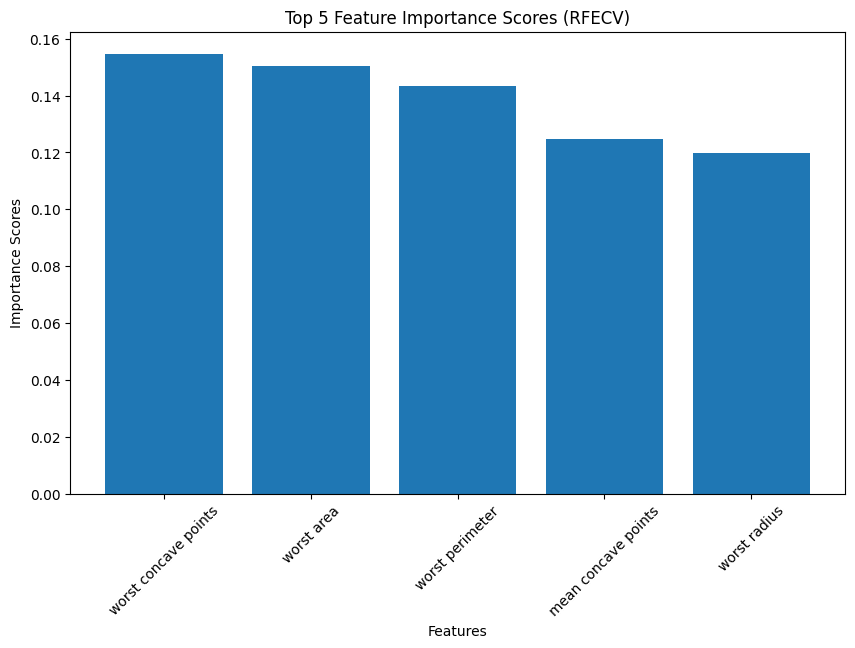

In [ ]:
# Get feature importance scores
features = feature_names[fit.support_]

# Sort features and importance scores in decreasing order
sorted_indices = np.argsort(fit.estimator_.feature_importances_)[::-1]
sorted_features = features[sorted_indices][:num_features]
sorted_importance_scores = fit.estimator_.feature_importances_[sorted_indices][:num_features]


plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importance_scores)), sorted_importance_scores, align="center")
plt.xticks(range(len(sorted_importance_scores)), sorted_features, rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance Scores")
plt.title("Top 5 Feature Importance Scores (RFECV)")
plt.show()

## Meta Selector

In [ ]:
# Set the number of features to select
num_features = 5

# 2. Feature Ranking with RFECV
model = RandomForestClassifier()
ms = SelectFromModel(estimator = model, max_features = num_features)
fit = ms.fit(X, y)

# Get feature importance scores
features = feature_names[fit.get_support()]

# Display final feature set
print("Final Feature Set:", features)

# Split the data into train and test sets using the top 5 features
selected_indices = np.isin(feature_names, selected_features)

# Select the corresponding columns in the NumPy array X
X_train_ms_selected_features = X_train[:, selected_indices]
X_test_ms_selected_features = X_test[:, selected_indices]


# Train the final model
final_model = RandomForestClassifier()
final_model.fit(X_train_ms_selected_features, y_train)

# Make predictions
y_pred_ms = final_model.predict(X_test_ms_selected_features)

# Evaluate the final model performance
final_accuracy = accuracy_score(y_test, y_pred_ms)
print(f"Final Accuracy with Selected Features: {final_accuracy * 100:.2f}%")

Final Feature Set: ['mean concave points' 'worst radius' 'worst perimeter' 'worst area'
 'worst concave points']
Final Accuracy with Selected Features: 97.37%


#**EMBEDDED**

##**Random Forest**

In [ ]:
num_features = 5

# Train a Random Forest classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Get feature importance scores
feature_importance_scores = clf.feature_importances_

# Get feature importance scores
sorted_indices = np.argsort(feature_importance_scores)[::-1][:num_features]
X_train_selected = X_train[:, sorted_indices]
X_test_selected = X_test[:, sorted_indices]

# Display final feature set
print("Final Feature Set:", feature_names[sorted_indices])

final_model = SVC()
final_model.fit(X_train_selected, y_train)

# Make predictions
y_pred = final_model.predict(X_test_selected)

# Evaluate the final model performance
final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final Accuracy with Selected Features: {final_accuracy * 100:.2f}%")

Final Feature Set: ['worst concave points' 'mean concave points' 'worst area' 'worst radius'
 'worst perimeter']
Final Accuracy with Selected Features: 92.98%


Selected Features: Index(['worst concave points', 'mean concave points', 'worst area',
       'worst radius', 'worst perimeter'],
      dtype='object')


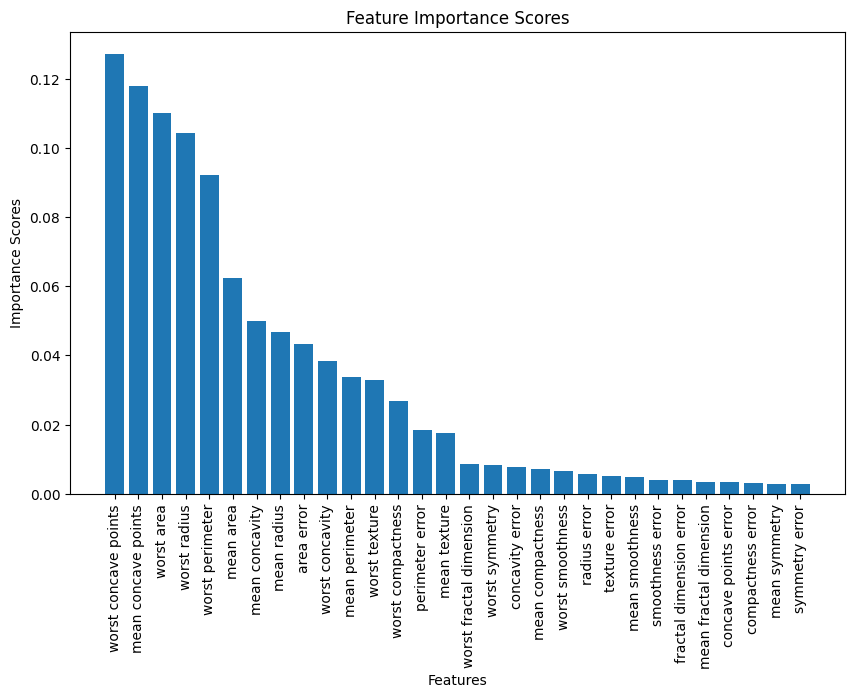

In [ ]:
# Sort feature importance scores and select top 5 features
sorted_indices = np.argsort(feature_importance_scores)[::-1][:5]
X_train_selected = X_train[:, sorted_indices]
X_test_selected = X_test[:, sorted_indices]

# Get the names of selected features
selected_feature_names = df.columns[:-1][sorted_indices]

# Print the names of selected features
print("Selected Features:", selected_feature_names)

# Sort features and importance scores in decreasing order
sorted_indices = np.argsort(feature_importance_scores)[::-1]
sorted_features = df.columns[sorted_indices]
sorted_importance_scores = feature_importance_scores[sorted_indices]

# Create a bar plot of feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importance_scores)), sorted_importance_scores, align="center")
plt.xticks(range(len(sorted_importance_scores)), sorted_features, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Scores")
plt.title("Feature Importance Scores")
plt.show()
